# CS 6410 Project - Poker Predictor
## Team: Wentao chen & Zhi Ling

### Player Action Prediction with Poker Dataset in GTO Strategy

#### Poker hand strength algorithm

In [1]:
from treys import Card, Evaluator
# --- Card Format Fix ---

suit_map = {'D': 'd', 'H': 'h', 'S': 's', 'C': 'c'}
rank_map = {
    '2': '2', '3': '3', '4': '4', '5': '5',
    '6': '6', '7': '7', '8': '8', '9': '9',
    'T': 'T', 'J': 'J', 'Q': 'Q', 'K': 'K', 'A': 'A'
}

def convert_card(card):
    if not isinstance(card, str) or len(card) != 2:
        return None
    suit, rank = card[0], card[1]
    return rank_map.get(rank, '') + suit_map.get(suit, '')

def parse_cards(card_str):
    return [convert_card(c.strip()) for c in card_str.split(',') if convert_card(c.strip())] if isinstance(card_str, str) else []

def get_board_for_street(row):
    cards = parse_cards(row['community_cards'])
    stage = row['stage']
    if stage == 3:
        return cards[:3]
    elif stage == 5:
        return cards[:4]
    else:
        return cards[:5]

# --- Hand Strength Evaluator ---

def evaluate_hand_strength(hole_cards, board_cards):
    evaluator = Evaluator()

    # Validate hole cards
    if not hole_cards or len(hole_cards) != 2:
        return -1, "Unknown"

    # Validate board cards (at least 3 for flop)
    if len(board_cards) < 3:
        return -1, "Unknown"

    # Make sure all cards are valid strings
    if any(card is None or len(card) != 2 for card in hole_cards + board_cards):
        return -1, "Unknown"

    # Convert to treys cards
    my_hand = [Card.new(card) for card in hole_cards]
    board = [Card.new(card) for card in board_cards]

    # Evaluate
    score = evaluator.evaluate(my_hand, board)
    hand_class = evaluator.class_to_string(evaluator.get_rank_class(score))
    return score, hand_class

#### Simulations for hole cards strength calculation

In [4]:
from treys import Card, Deck, Evaluator
from itertools import combinations
import random
from collections import defaultdict
import tqdm

evaluator = Evaluator()

# All 13 ranks
ranks = 'AKQJT98765432'

# Build all 169 canonical hand keys (e.g., 'AKs', 'QJo', '77')
def generate_preflop_keys():
    keys = []
    for i in range(len(ranks)):
        for j in range(len(ranks)):
            r1, r2 = ranks[i], ranks[j]
            if i < j:
                keys.append(f"{r1}{r2}s")  # suited
            elif i > j:
                keys.append(f"{r2}{r1}o")  # offsuit
            else:
                keys.append(f"{r1}{r2}")   # pair
    return keys

# Convert canonical key to actual card combos
def get_hole_card_combos(key):
    suits = ['h', 'd', 'c', 's']
    combos = []

    if len(key) == 2:  # pocket pair
        rank = key[0]
        for s1, s2 in combinations(suits, 2):
            combos.append((rank + s1, rank + s2))
    else:
        r1, r2 = key[0], key[1]
        if key[2] == 's':  # suited
            for s in suits:
                combos.append((r1 + s, r2 + s))
        else:  # offsuit
            for s1 in suits:
                for s2 in suits:
                    if s1 != s2:
                        combos.append((r1 + s1, r2 + s2))
    return combos

# Main simulation
def simulate_hand_strength(key, simulations_per_combo=100):
    combos = get_hole_card_combos(key)
    total_score = 0
    total_trials = 0

    for hc1, hc2 in combos:
        wins = 0
        ties = 0
        my_cards = [Card.new(hc1), Card.new(hc2)]

        for _ in range(simulations_per_combo):
            deck = Deck()
            for c in my_cards:
                deck.cards.remove(c)

            opp = deck.draw(2)
            board = [deck.draw(1)[0] for _ in range(5)]

            my_score = evaluator.evaluate(my_cards, board)
            opp_score = evaluator.evaluate(opp, board)

            if my_score < opp_score:
                wins += 1
            elif my_score == opp_score:
                ties += 1

        total_score += (wins + ties * 0.5) / simulations_per_combo
        total_trials += 1

    return round(total_score / total_trials, 4)

# Generate strength map
preflop_strength_map = {}
keys = generate_preflop_keys()

print("Simulating preflop strengths...")
for key in tqdm.tqdm(keys):
    strength = simulate_hand_strength(key, simulations_per_combo=100)
    preflop_strength_map[key] = strength

# Print sample
#for k in sorted(preflop_strength_map.keys()):
    #print(f"{k}: {preflop_strength_map[k]}")


Simulating preflop strengths...


100%|██████████| 169/169 [00:04<00:00, 37.82it/s]


#### Data loading and processing

In [7]:
import pandas as pd
df = pd.read_csv('gto_poker_data_large_size.csv', low_memory=False)

action_columns = [col for col in df.columns if col.startswith('action_') and '_type' in col]
max_actions = max(int(col.split('_')[1]) for col in action_columns)

rows = []

def get_preflop_key(hole_cards):
    if len(hole_cards) != 2 or None in hole_cards:
        return None

    rank1, suit1 = hole_cards[0][0], hole_cards[0][1]
    rank2, suit2 = hole_cards[1][0], hole_cards[1][1]

    suited = suit1 == suit2
    ranks = sorted([rank1, rank2], reverse=True)
    if rank1 == rank2:
        return ranks[0] + ranks[1]
    return ranks[0] + ranks[1] + ('s' if suited else 'o')

for _, row in df.iterrows():
    for i in range(2, max_actions + 1, 2):  # Player1 actions
        type_col = f'action_{i}_type'
        pot_col = f'action_{i}_pot'
        street_col = f'action_{i}_street'
        pre_col = f'action_{i}_encoded_past_actions'
        bet_col = f'action_{i}_bet_percentage'

        if pd.isna(row.get(type_col)):
            continue

        action_type = row[type_col]
        action_street = row[street_col] if street_col in row and not pd.isna(row[street_col]) else ''
        pot = row[pot_col]
        pre_action = row[pre_col]
        bet_percentage = row[bet_col]
        
        def get_board(row, i):
            cards = parse_cards(row['community_cards'])
            street = row.get(f'action_{i}_street', '')
            if street == 'preflop':
                return []
            elif street == 'flop':
                return cards[:3]
            elif street == 'turn':
                return cards[:4]
            elif street == 'river':
                return cards[:5]
            else:
                return []

        hole_cards = parse_cards(row['hole_cards'])
        board_cards = get_board(row, i)
        hand_strength, hand_class = evaluate_hand_strength(hole_cards, board_cards)

        preflop_key = get_preflop_key(hole_cards)
        preflop_strength = preflop_strength_map.get(preflop_key, -1)

        flat_row = {
            'action_type': action_type,
            'action_street': action_street,
            'pot': pot,
            'previous_action': pre_action,
            'bet_percentage': round(bet_percentage, 4),
            'preflop_strength': preflop_strength,
            'hand_strength': hand_strength,
            'hand_class': hand_class
        }

        rows.append(flat_row)

flattened_df = pd.DataFrame(rows)

# Optional: Save
# flattened_df.to_csv('flattened_output.csv', index=False)
print(flattened_df.head(5))


  action_type action_street    pot  previous_action  bet_percentage  \
0        call       preflop   20.0     2.143000e+04             0.0   
1        call       preflop   20.0     2.143000e+04             0.0   
2        call          flop   46.0     2.171020e+06             0.0   
3        call          turn  106.0     2.171356e+08             0.0   
4        fold         river  177.0     2.171360e+10             0.0   

   preflop_strength  hand_strength hand_class  
0            0.4487             -1    Unknown  
1            0.5367             -1    Unknown  
2            0.5367           7018  High Card  
3            0.5367           6351  High Card  
4            0.5367           6351  High Card  


#### Data transforming

In [9]:
from sklearn.preprocessing import LabelEncoder

# Categorical columns to encode
categorical_cols = [
    'action_type',
    'hand_class',
    'action_street'
]

# Encode each using LabelEncoder
for col in categorical_cols:
    le = LabelEncoder()
    flattened_df[col] = le.fit_transform(flattened_df[col])

print(flattened_df)

      action_type  action_street     pot  previous_action  bet_percentage  \
0               0              1    20.0     2.143000e+04          0.0000   
1               0              1    20.0     2.143000e+04          0.0000   
2               0              0    46.0     2.171020e+06          0.0000   
3               0              3   106.0     2.171356e+08          0.0000   
4               1              2   177.0     2.171360e+10          0.0000   
...           ...            ...     ...              ...             ...   
9606            1              3  1314.0     2.877991e+12          0.0000   
9607            2              1    80.0     2.271500e+04         52.6316   
9608            2              1   160.0     2.294403e+06         35.2941   
9609            1              0   180.0     2.294644e+08          0.0000   
9610            0              1    60.0     2.260000e+04          0.0000   

      preflop_strength  hand_strength  hand_class  
0               0.4487 

#### Player action classification training


===== XGBoost =====
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       599
           1       0.99      0.96      0.97       452
           2       0.96      0.98      0.97       872

    accuracy                           0.97      1923
   macro avg       0.97      0.97      0.97      1923
weighted avg       0.97      0.97      0.97      1923



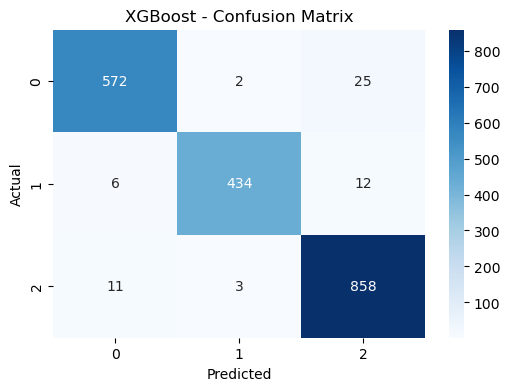


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       599
           1       0.98      0.94      0.96       452
           2       0.94      0.98      0.96       872

    accuracy                           0.95      1923
   macro avg       0.96      0.95      0.95      1923
weighted avg       0.95      0.95      0.95      1923



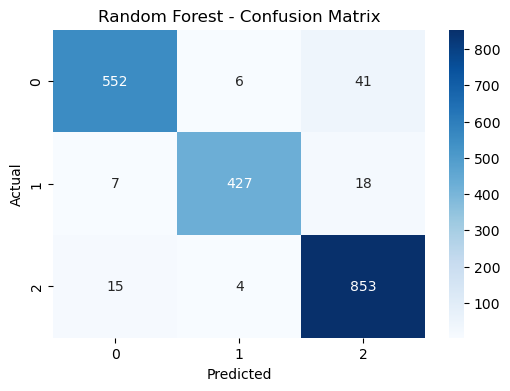


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       599
           1       0.00      0.00      0.00       452
           2       0.45      1.00      0.62       872

    accuracy                           0.45      1923
   macro avg       0.15      0.33      0.21      1923
weighted avg       0.21      0.45      0.28      1923



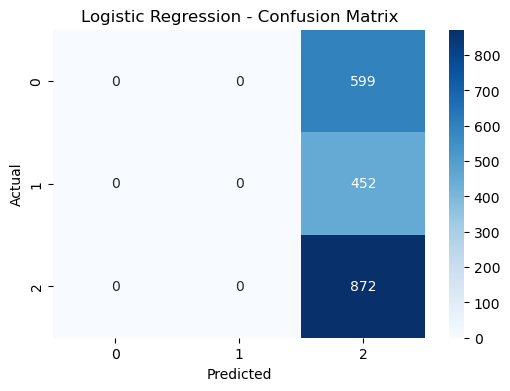

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Split dataset for classification
# -----------------------------
X_classification = flattened_df.drop(columns=['action_type', 'bet_percentage'])
y_classification = flattened_df['action_type']

X_train, X_test, y_train, y_test = train_test_split(
    X_classification, y_classification, test_size=0.2, random_state=42
)

# -----------------------------
# 2. Helper function to evaluate and plot
# -----------------------------
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# -----------------------------
# 3. Train & evaluate XGBoost
# -----------------------------
xgb_clf = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42
)
xgb_clf.fit(X_train, y_train)
evaluate_model("XGBoost", xgb_clf, X_test, y_test)

# -----------------------------
# 4. Train & evaluate Random Forest
# -----------------------------
rf_clf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_clf.fit(X_train, y_train)
evaluate_model("Random Forest", rf_clf, X_test, y_test)

# -----------------------------
# 5. Train & evaluate Logistic Regression
# -----------------------------
lr_clf = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced'
)
lr_clf.fit(X_train, y_train)
evaluate_model("Logistic Regression", lr_clf, X_test, y_test)


#### Player raise percentage regression training


===== Random Forest Regressor =====
MAE : 1.8968
RMSE: 5.1848
R²   : 0.9226


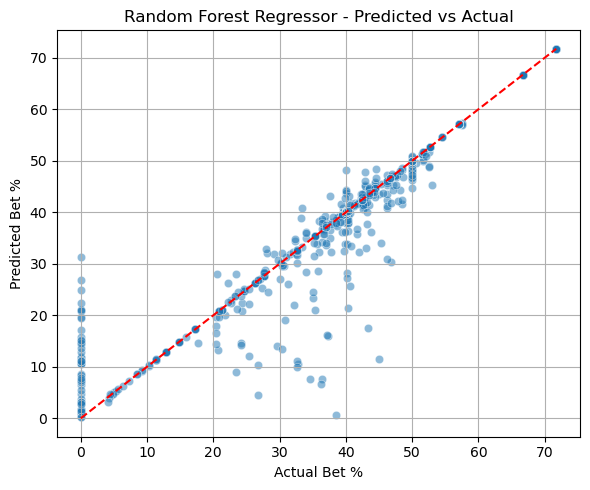

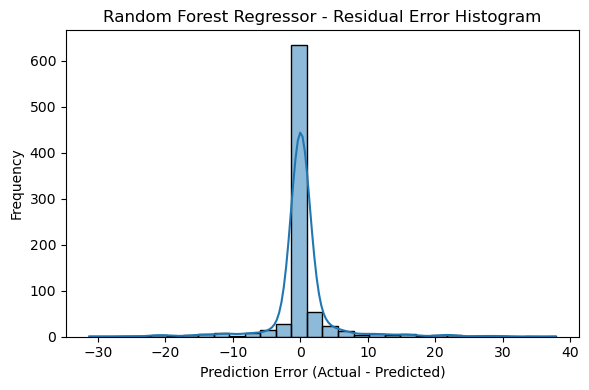


===== Gradient Boosting Regressor =====
MAE : 3.4235
RMSE: 5.9628
R²   : 0.8976


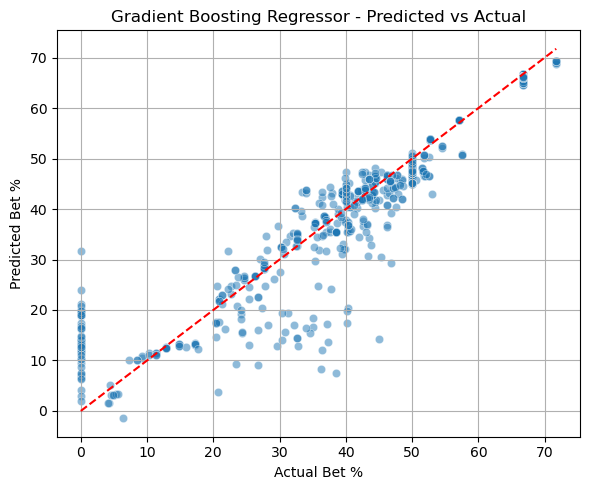

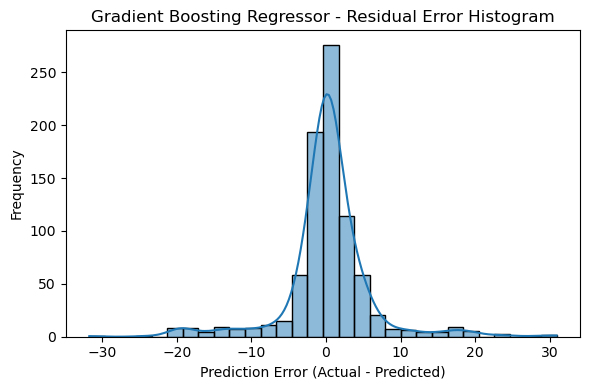


===== Linear Regression =====
MAE : 9.8434
RMSE: 12.4332
R²   : 0.5546


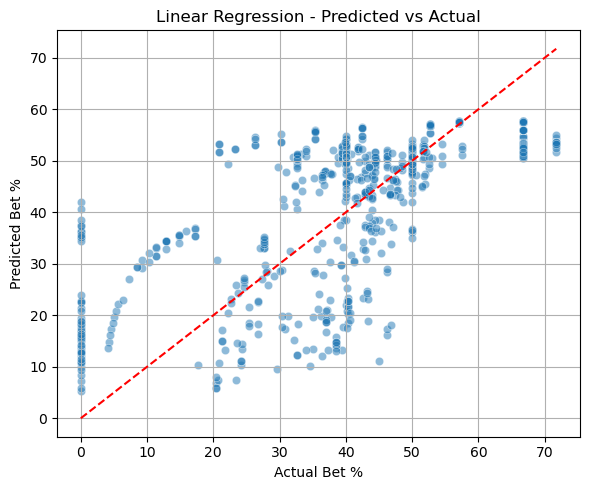

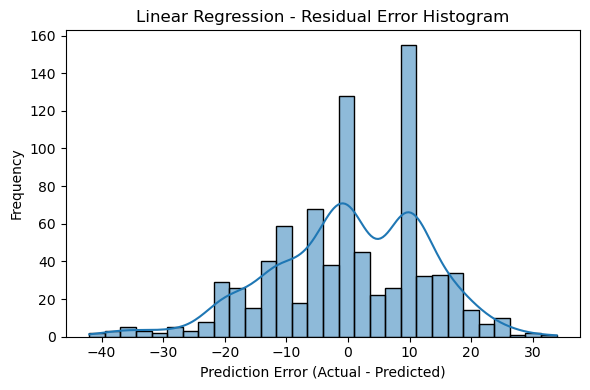

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# ---------------------------------------------
# 1. Filter rows where action_type == 'raise'
# ---------------------------------------------
raise_encoded_value = flattened_df['action_type'].value_counts().idxmax()  # or manually lookup
df_raise = flattened_df[flattened_df['action_type'] == raise_encoded_value]

# ---------------------------------------------
# 2. Prepare features and target
# ---------------------------------------------
X = df_raise.drop(columns=['action_type', 'bet_percentage'])  # drop action_type and target
y = df_raise['bet_percentage']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------
# 3. Evaluation + Plotting function
# ---------------------------------------------
def evaluate_regression(model, name, X_test, y_test):
    y_pred = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n===== {name} =====")
    print("MAE :", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R²   :", round(r2, 4))

    # Plot 1: Predicted vs Actual
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f"{name} - Predicted vs Actual")
    plt.xlabel("Actual Bet %")
    plt.ylabel("Predicted Bet %")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot 2: Residual Error Histogram
    residuals = y_test - y_pred
    plt.figure(figsize=(6, 4))
    sns.histplot(residuals, bins=30, kde=True)
    plt.title(f"{name} - Residual Error Histogram")
    plt.xlabel("Prediction Error (Actual - Predicted)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------
# 4. Train and evaluate models
# ---------------------------------------------

# Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
evaluate_regression(rf_reg, "Random Forest Regressor", X_test, y_test)

# Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_reg.fit(X_train, y_train)
evaluate_regression(gb_reg, "Gradient Boosting Regressor", X_test, y_test)

# Linear Regression
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
evaluate_regression(lr_reg, "Linear Regression", X_test, y_test)


#### Models storage

In [29]:
import joblib
from sklearn.preprocessing import LabelEncoder

# Fit LabelEncoder on original action labels
action_encoder = LabelEncoder()
action_encoder.fit(flattened_df['action_type'])

# Save models
joblib.dump(xgb_clf, 'xgb_classifier.pkl')
joblib.dump(rf_reg, 'rf_regressor.pkl')
joblib.dump(action_encoder, 'action_type_encoder.pkl')

# Save feature column lists
joblib.dump(list(X_classification.columns), 'classifier_features.pkl')
joblib.dump(list(X.columns), 'regressor_features.pkl')

['regressor_features.pkl']

#### Predict function

In [39]:
import joblib
import pandas as pd

# Load models and features
xgb_clf = joblib.load('xgb_classifier.pkl')
rf_reg = joblib.load('rf_regressor.pkl')
classifier_features = joblib.load('classifier_features.pkl')
regressor_features = joblib.load('regressor_features.pkl')

# Define label map manually
label_map = {
    0: 'call',
    1: 'fold',
    2: 'raise'
}
raise_index = 2  # Adjust this based on your label order

def predict_action_and_bet(user_input: dict):
    df_cls = pd.DataFrame([user_input])[classifier_features]
    action_encoded = int(xgb_clf.predict(df_cls)[0])
    action_label = label_map[action_encoded]

    if action_encoded == raise_index:
        df_reg = pd.DataFrame([user_input])[regressor_features]
        predicted_bet = float(rf_reg.predict(df_reg)[0])
    else:
        predicted_bet = None

    return action_label, predicted_bet


#### Example usage

In [41]:
sample_input = {
    'action_street': 1,
    'pot': 120.0,
    'previous_action': 275000.0,
    'hand_strength': 6780,
    'hand_class': 3,
    'preflop_strength': 0.7511,
}

pred_action, pred_bet = predict_action_and_bet(sample_input)

print("Predicted Action:", pred_action)
if pred_bet is not None:
    print("Predicted Bet Percentage:", round(pred_bet, 2))


Predicted Action: raise
Predicted Bet Percentage: 60.35
